<h1> Imports & Installs </h1>

In [9]:
!pip install scikit-image


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from scipy import ndimage
from skimage.feature import blob_log
from skimage.color import rgb2gray

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 8)

<h1> Loading Image </h1>

In [20]:
# For now, the Image Path must be set.
IMAGE_PATH = "images/edited image.jpg"  

try:
    image = np.array(Image.open(IMAGE_PATH).convert("RGB"))
    print(f"Loaded image: {IMAGE_PATH}, shape={image.shape}")
except FileNotFoundError:
    image = None
    print("No file found at IMAGE_PATH. Run the next cell to generate a synthetic starfield instead.")

Loaded image: images/edited image.jpg, shape=(2268, 4032, 3)


# Normalizing / Greyscale the Image
<li> Note: Most of these steps can be substitute via Joey's Algorithm handling the Filtering / Pre-Processing Section</li>

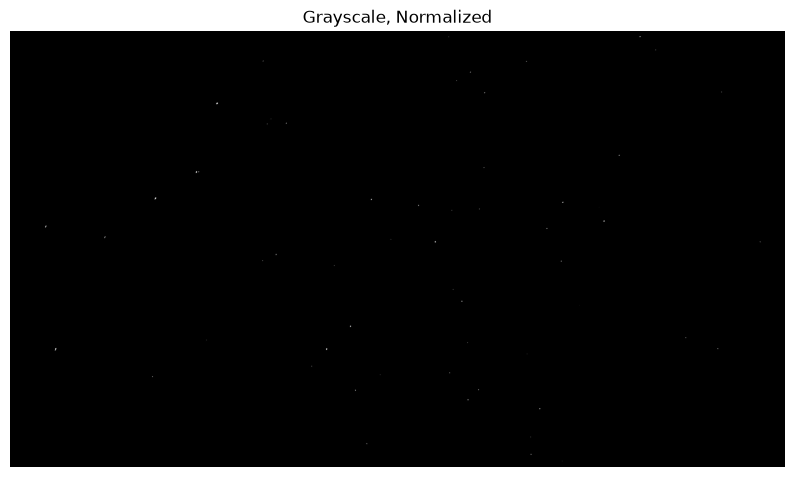

In [21]:
gray = rgb2gray(image)  # values now in range [0, 1]

# Normalize to use the full 0-1 range, in case the image doesn't already
gray_norm = (gray - gray.min()) / (gray.max() - gray.min())

plt.imshow(gray_norm, cmap='gray')
plt.title("Grayscale, Normalized")
plt.axis('off')
plt.show()

<h1> Filtering Phase </h1>

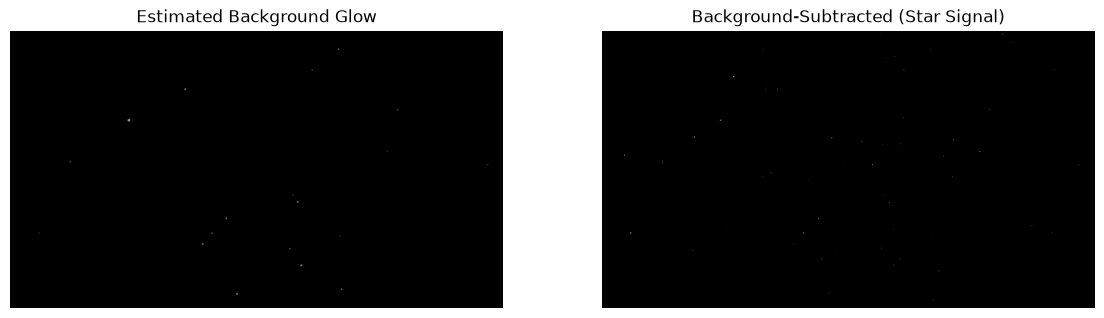

In [22]:
# A large median filter smooths out small bright dots (stars) but keeps
# the slow-varying background glow intact.
background_estimate = ndimage.median_filter(gray_norm, size=25)

# Subtracting it leaves mostly just the sharp, star-like features
star_signal = gray_norm - background_estimate
star_signal = np.clip(star_signal, 0, None)  # discard negative dips

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(background_estimate, cmap='gray')
axes[0].set_title("Estimated Background Glow")
axes[0].axis('off')
axes[1].imshow(star_signal, cmap='gray')
axes[1].set_title("Background-Subtracted (Star Signal)")
axes[1].axis('off')
plt.show()

<h1> Candidate Star Detection via Blobs</h1>

In [23]:
blobs = blob_log(
    star_signal,
    min_sigma=1,
    max_sigma=4,
    num_sigma=8,
    threshold=0.05
)

# blob_log returns (y, x, sigma) for each detection.
# Convert sigma to an approximate display radius.
blobs[:, 2] = blobs[:, 2] * np.sqrt(2)

print(f"Detected {len(blobs)} candidate stars before filtering.")

Detected 62 candidate stars before filtering.


In [24]:
MIN_BRIGHTNESS = 0.15   # minimum normalized pixel value to count as a real star
EDGE_MARGIN = 5         # pixels away from the border required

filtered_blobs = []
for (y, x, r) in blobs:
    y, x = int(round(y)), int(round(x))
    if not (EDGE_MARGIN <= y < gray_norm.shape[0] - EDGE_MARGIN):
        continue
    if not (EDGE_MARGIN <= x < gray_norm.shape[1] - EDGE_MARGIN):
        continue
    brightness = gray_norm[y, x]
    if brightness < MIN_BRIGHTNESS:
        continue
    filtered_blobs.append((y, x, r, brightness))

print(f"{len(filtered_blobs)} stars remain after filtering (from {len(blobs)} candidates).")

62 stars remain after filtering (from 62 candidates).


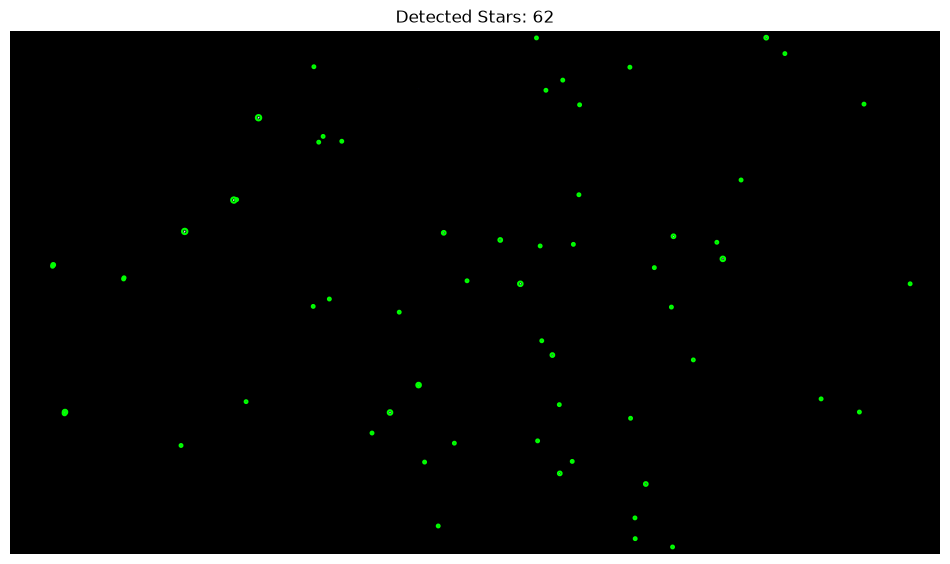

In [25]:
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(image)
ax.set_title(f"Detected Stars: {len(filtered_blobs)}")
ax.axis('off')

for (y, x, r, brightness) in filtered_blobs:
    circle = patches.Circle((x, y), radius=max(r * 3, 6), fill=False,
                             edgecolor='lime', linewidth=1.5)
    ax.add_patch(circle)

plt.show()

In [18]:
# Displaying the Star Candidates in a dataframe
import pandas as pd

results_df = pd.DataFrame(
    filtered_blobs, columns=["y (row)", "x (col)", "size (sigma)", "brightness (0-1)"]
).sort_values("brightness (0-1)", ascending=False).reset_index(drop=True)

results_df

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,y (row),x (col),size (sigma),brightness (0-1)
0,1020,184,2.626397,0.997488
1,1660,235,2.626397,0.995813
2,890,2876,3.232488,0.993302
3,1197,2867,2.626397,0.990790
4,733,970,4.444671,0.988278
...,...,...,...,...
70,707,2151,1.414214,0.397331
71,1837,1766,2.626397,0.389450
72,869,819,2.020305,0.388132
73,1459,2062,2.626397,0.371147


# KNN Section
<p> Pathways (For Latitide)</p>
<li> Identification through North Star (Exclusive to North Hemisphere)
    <li>
        asd
    </li>
<li> Identification Using Southern Cross (Exclusive to South Hemisphere)
<li> Identification Using Rising and Setting Positions of Constellations
</li>


In [26]:
class Star_KNN:
  def __init__(self, k):
    self.k = k

  #Train Model on Images
  def fit(self, X_train, y_train):
    return

  #Euclidean Distance Function
  def Euclidean_distance(self, x1, x2):
    return np.sqrt(np.sum((x1-x2)**2))

  #Manhattan Distance Function
  def Manhattan_distance(self, x1, x2):
    return np.sum(np.abs(x1 - x2))

  #Minkowski Distance Function
  def Minkowski_distance(self, x1, x2, p):
    return (np.sum(np.abs(x1- x2)**p))**(1/p)
